<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/K_MeansClus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

**K-Means Clustering** is one of the most popular unsupervised machine learning algorithms. It is used to group unlabelled data points into distinct, non-overlapping groups called **clusters** based on feature similarity.

The goal of the algorithm is to minimize the distance between data points within the same cluster and maximize the distance between different clusters.

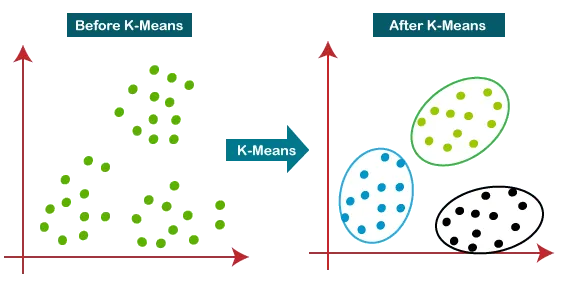
## How It Works Step-by-Step

Imagine you have a scatter plot of data points with no labels, and you want to group them into $K$ distinct packs. K-Means achieves this through an iterative process:

* **Step 1: Choose K** – Define the number of clusters ($K$) you want to find.
* **Step 2: Initialize Centroids** – Randomly pick $K$ data points to act as the initial center points (centroids).
* **Step 3: Assign Points** – Calculate the distance from every data point to all $K$ centroids. Assign each data point to its closest centroid.

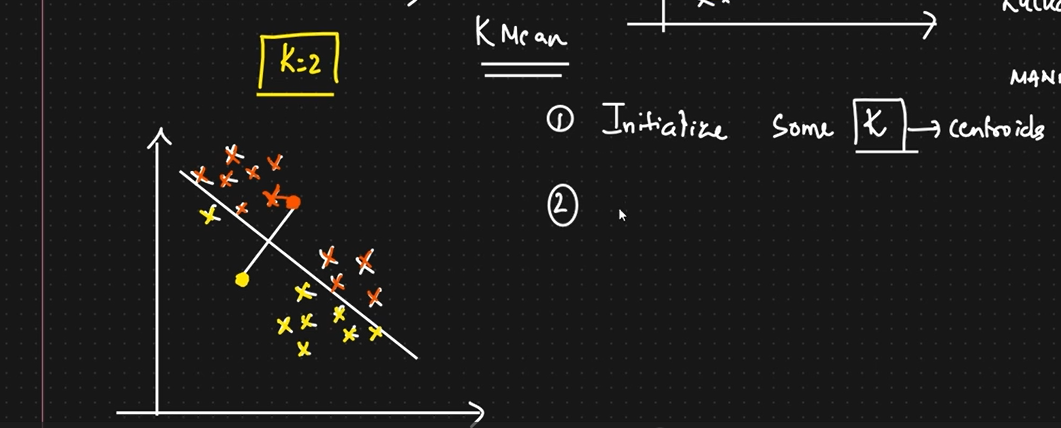

* **Step 4: Update Centroids** – Calculate the mean of all data points assigned to a cluster. Move the centroid to this new mean position.

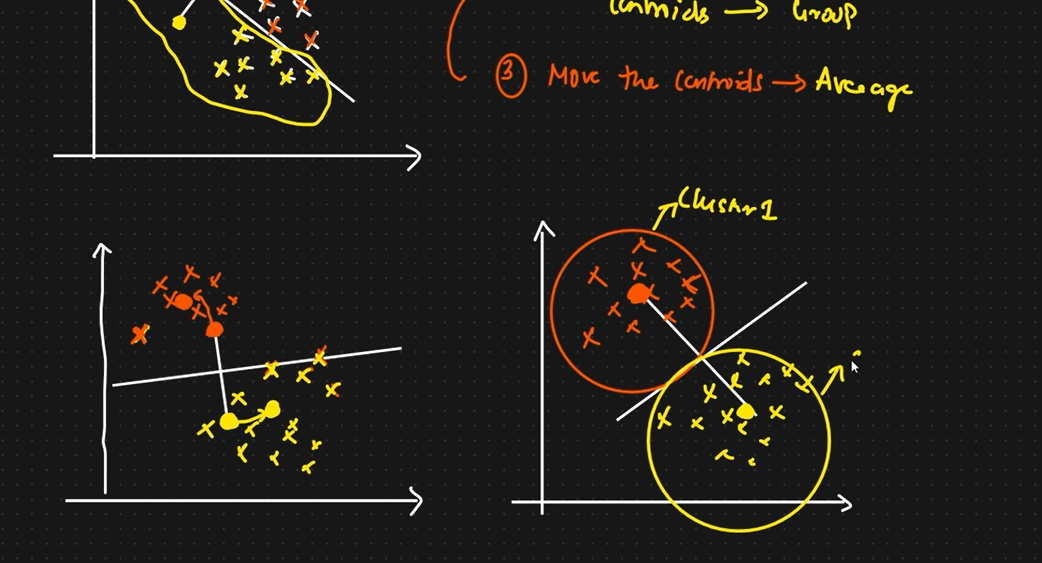

* **Step 5: Repeat** – Keep repeating Steps 3 and 4 until the centroids stop shifting or the maximum number of iterations is reached.


## Mathematical Foundations

### 1. Distance Metric (Euclidean Distance)
To determine which cluster a data point belongs to, K-Means calculates the straight-line distance between the data point $x_i$ and a centroid $c_j$. For a $d$-dimensional space, this is defined as:

$$d(x_i, c_j) = \sqrt{\sum_{m=1}^{d} (x_{im} - c_{jm})^2}$$

### 2. Objective Function (Inertia)
The algorithm mathematically tries to minimize the **Within-Cluster Sum of Squares (WCSS)**, which is also known as inertia. The formula is:

$$J = \sum_{j=1}^{K} \sum_{x_i \in S_j} \| x_i - c_j \|^2$$

Where:
* $K$ is the total number of clusters.
* $S_j$ is the set of data points belonging to cluster $j$.
* $c_j$ is the centroid of cluster $j$.
* $\| x_i - c_j \|^2$ is the squared Euclidean distance between point $x_i$ and centroid $c_j$.


## How to Find the Optimal $K$: The Elbow Method

Choosing the right value for $K$ can be tricky if you do not know the underlying patterns of your dataset. Data scientists use the **Elbow Method** to solve this:

1. Run the K-Means algorithm multiple times, changing $K$ from $1$ to $10$.
2. Calculate the **WCSS (Inertia)** value for each run.
3. Plot a line chart where the x-axis is the **Number of Clusters ($K$)** and the y-axis is the **WCSS**.
4. Look for the **"Elbow Point"** on the graph. This is the point where the rate of decrease drops sharply and levels off. This point represents the optimal $K$.


## Pros and Cons of K-Means

### Advantages
* **Fast and Scalable:** Computes quickly even on large datasets.
* **Easy to Implement:** Simple to understand and translate into programming code.
* **Guaranteed Convergence:** The algorithm always finds a final stable grouping.

### Disadvantages
* **Sensitive to Initialization:** Random placement of initial centroids can lead to different final clusters. (Mitigated using `K-Means++`).
* **Hardcoded K:** You must manually choose the value of $K$ beforehand.
* **Sensitive to Outliers:** Extreme data values can heavily distort the mean calculations and shift centroids incorrectly.
* **Assumes Spherical Clusters:** Fails on complex, non-linear shapes (like interlaced rings or moons).


# ***Find K values***


---

# Within-Cluster Sum of Squares (WCSS)

**Within-Cluster Sum of Squares (WCSS)**, also frequently called **Inertia**, is the primary metric used to evaluate the quality of a K-Means clustering model. It measures how tightly packed or compact the data points are inside their assigned clusters.

The smaller the WCSS value, the more compact and well-defined your clusters are.


## The Mathematical Formula

Mathematically, WCSS calculates the sum of the squared distances between each data point and its respective cluster centroid. The formula is expressed as:

$$\text{WCSS} = \sum_{j=1}^{K} \sum_{x_i \in S_j} ||x_i - c_j||^2$$

Where:
* $K$ is the total number of clusters.
* $S_j$ is the set containing all data points assigned to cluster $j$.
* $c_j$ is the centroid (mean position) of cluster $j$.
* $x_i$ is an individual data point within cluster $S_j$.
* $||x_i - c_j||^2$ represents the squared Euclidean distance from the point to its centroid.

## Step-by-Step Calculation Example

Imagine you run K-Means with $K=2$ on a simple 1D dataset. Your algorithm creates two clusters:
* **Cluster 1:** Points $[1, 2, 3]$ $\rightarrow$ Centroid $c_1 = 2$
* **Cluster 2:** Points $[8, 10, 12]$ $\rightarrow$ Centroid $c_2 = 10$

### Step 1: Calculate Squared Distances for Cluster 1
$$\text{Dist}_1 = (1 - 2)^2 + (2 - 2)^2 + (3 - 2)^2$$
$$\text{Dist}_1 = (-1)^2 + (0)^2 + (1)^2 = 1 + 0 + 1 = 2$$

### Step 2: Calculate Squared Distances for Cluster 2
$$\text{Dist}_2 = (8 - 10)^2 + (10 - 10)^2 + (12 - 10)^2$$
$$\text{Dist}_2 = (-2)^2 + (0)^2 + (2)^2 = 4 + 0 + 4 = 8$$

### Step 3: Sum All Clusters to Find Total WCSS
$$\text{WCSS} = \text{Dist}_1 + \text{Dist}_2 = 2 + 8 = 10$$


## WCSS and the Elbow Method

The main challenge in unsupervised learning is choosing the correct number of clusters ($K$). WCSS is the backbone tool used to solve this via the **Elbow Method**:

1. If $K = 1$ (all data in one cluster), WCSS is at its maximum value.
2. If $K = N$ (every data point is its own cluster centroid), WCSS drops to exactly **$0$**.
3. As $K$ increases, WCSS will naturally drop. We plot $K$ vs. WCSS on a line graph.
4. We select the **"Elbow Point"**—the specific value of $K$ where WCSS stops dropping rapidly and begins to decrease slowly or level off linearly.


## Limitations of WCSS

* **Scale Sensitive:** WCSS changes drastically based on data scaling. If you multiply your data features by 10, your WCSS will skyrocket. **Always scale/standardize data before computing WCSS.**
* **Monotonically Decreasing:** WCSS always goes down when you add more clusters, even if those clusters are completely meaningless. It cannot be used alone without a visualization plot (like the Elbow curve) or pairing it with Silhouette Scores.

# The Elbow Method

The **Elbow Method** is a popular heuristic technique used in unsupervised machine learning to determine the optimal number of clusters ($K$) for algorithms like K-Means.

Because K-Means requires you to specify the number of clusters beforehand, the Elbow Method provides a data-driven way to choose the best $K$ by balancing cluster compactness with model simplicity.


## How It Works Under the Hood

The method uses the metric **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**. WCSS measures the total squared distance between every data point and its assigned cluster centroid.

1. **Iterate over $K$:** The K-Means algorithm is run multiple times, systematically changing the number of clusters (typically from $K = 1$ to $K = 10$).
2. **Calculate WCSS:** For each configuration of $K$, the final WCSS value is recorded.
3. **Plot the Curve:** A line graph is plotted where:
    * The **X-axis** represents the Number of Clusters ($K$).
    * The **Y-axis** represents the WCSS (Inertia).


## Interpreting the "Elbow Point"

As the number of clusters $K$ increases, the WCSS value will naturally decrease. This happens because adding more centroids places them closer to individual data points.

$$\lim_{K \to N} \text{WCSS} = 0$$

*(Where $N$ is the total number of data points in the dataset).*

To choose the optimal $K$, you look for the **"Elbow"** of the curve. This is the distinct point where:
* The sharp, rapid drop in WCSS slows down significantly.
* Adding more clusters yields diminishing returns (only minor improvements in WCSS).
* The curve begins to level off and transition into a flatter, more linear trajectory.

The value of $K$ at this specific bend represents the optimal balance point.


## Mathematical Representation of the Curve Plot

The line chart plots the relationship between the chosen hyperparameter $K$ and the cost function $J$ (WCSS):

$$J(K) = \sum_{j=1}^{K} \sum_{x_i \in S_j} \| x_i - c_j \|^2$$

A typical visualization curve transitions through three distinct phases:

* **Under-Clustered Zone ($K < \text{Optimal}$):** Steep downward slope. High WCSS variations mean clusters are too broad and overlapping.
* **The Elbow Point ($K = \text{Optimal}$):** The inflection point of the graph.
* **Over-Clustered Zone ($K > \text{Optimal}$):** Flat or gently sloping line. The data is being artificially split into redundant sub-clusters, risking model overfitting.


## Limitations of the Elbow Method

* **Ambiguous Curves:** On real-world datasets that are smooth or highly continuous, the curve might look like a smooth, rounded arc without a clear, sharp "elbow" point.
* **Subjective Assessment:** Visually identifying the exact location of the bend can vary slightly from person to person.
* **Alternative Solutions:** When the Elbow Method is inconclusive, data scientists often use the **Silhouette Method** as a quantitative backup to verify cluster quality.

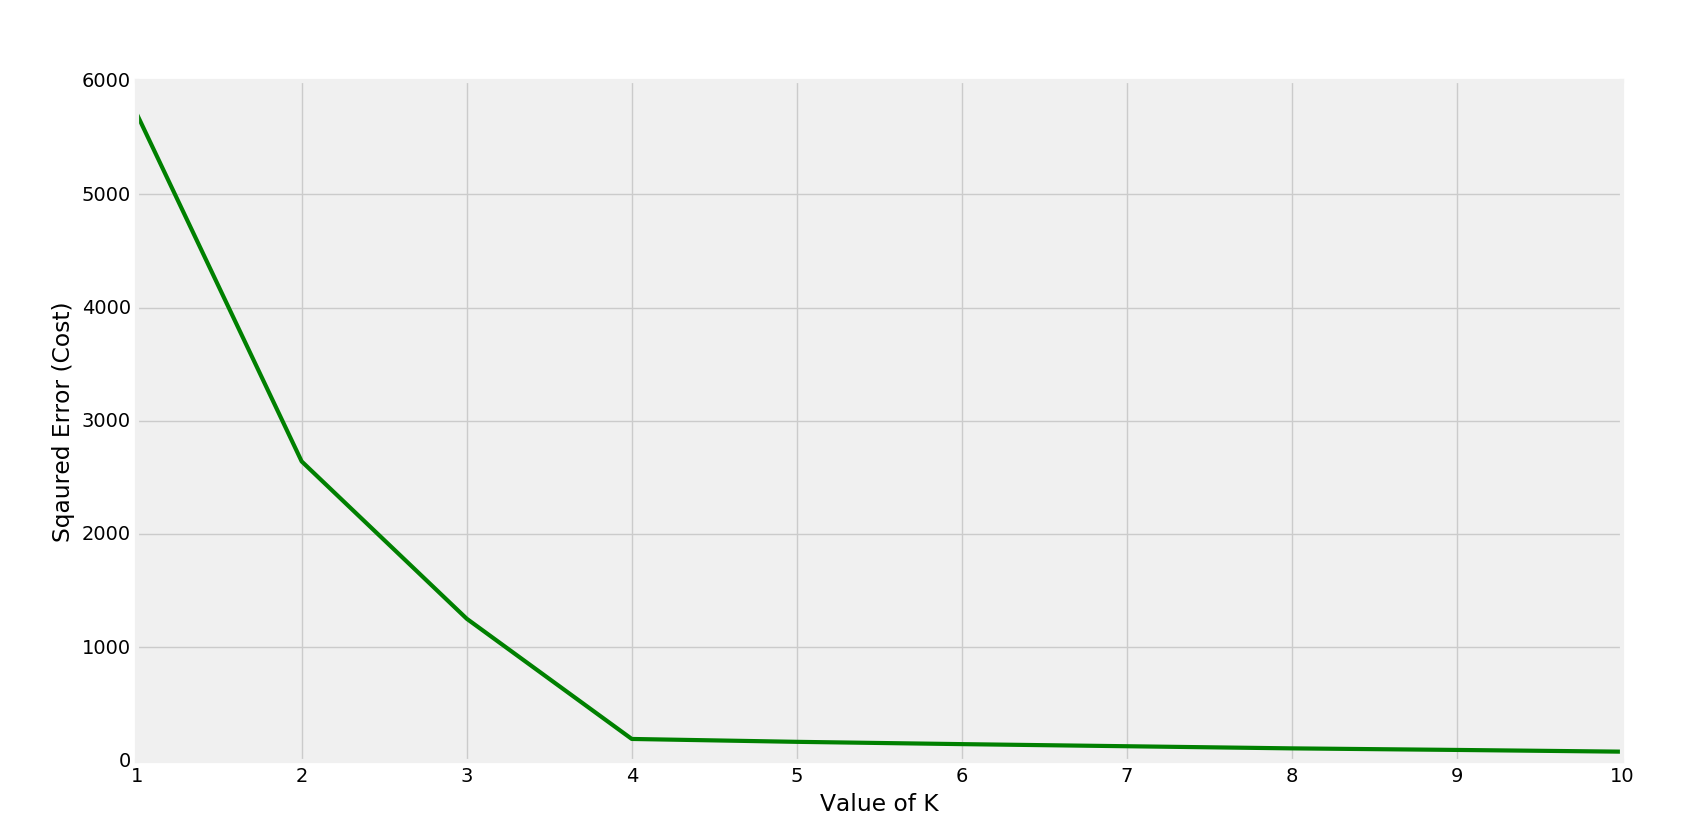

#here the value of k=4


# Distance Metrics: Manhattan vs. Euclidean Distance

---



Distance metrics are fundamental mathematical formulas used in machine learning algorithms like K-Means Clustering, K-Nearest Neighbors (KNN), and various optimization tasks to measure the similarity or dissimilarity between two data points.

## 1. Euclidean Distance

**Euclidean Distance** is the most common metric used to calculate the straight-line distance between two points in a Euclidean space. It represents the shortest possible path ("as the crow flies") between those two coordinates.

### Mathematical Formula
In a 2D space, the Euclidean distance $d_E$ between point $P_1(x_1, y_1)$ and point $P_2(x_2, y_2)$ is given by the Pythagorean theorem:

$$d_E = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

For a multi-dimensional space with $n$ features, the generalized formula is:

$$d_E = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$


## 2. Manhattan Distance

**Manhattan Distance** (also known as Taxi-cab distance, City Block distance, or $L_1$ norm) calculates the distance by traveling only along grid-like, axis-aligned paths. It mimics navigating the grid layout of streets in Manhattan, where you cannot walk through buildings diagonally and must instead take horizontal and vertical steps.

### Mathematical Formula
In a 2D space, the Manhattan distance $d_M$ between point $P_1(x_1, y_1)$ and point $P_2(x_2, y_2)$ is the sum of the absolute differences of their coordinates:

$$d_M = |x_2 - x_1| + |y_2 - y_1|$$

For a multi-dimensional space with $n$ features, the generalized formula is:

$$d_M = \sum_{i=1}^{n} |q_i - p_i|$$

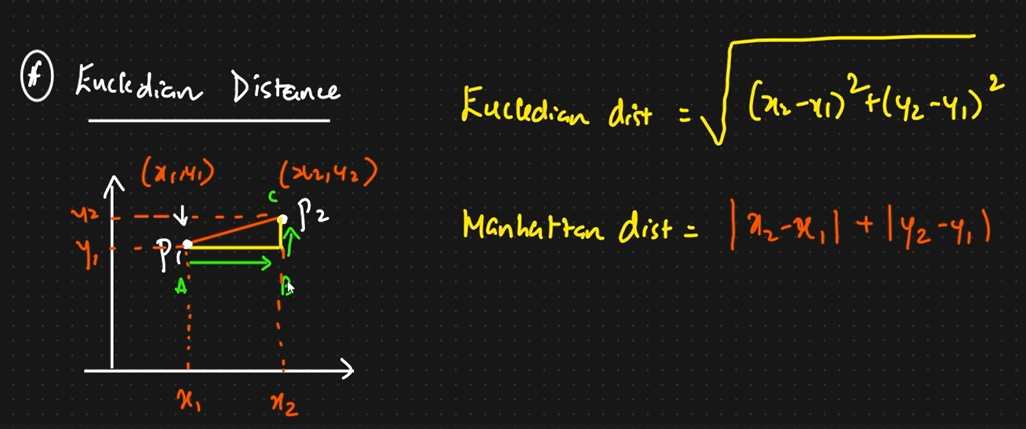


## Step-by-Step Calculation Example

Let's calculate both distances between two coordinates in a 2D space:
* **Point 1 ($P_1$):** $(1, 2)$ where $x_1 = 1, y_1 = 2$
* **Point 2 ($P_2$):** $(5, 5)$ where $x_2 = 5, y_2 = 5$

### Step 1: Calculate Euclidean Distance
Substitute the coordinate values into the Euclidean equation:

$$d_E = \sqrt{(5 - 1)^2 + (5 - 2)^2}$$

$$d_E = \sqrt{(4)^2 + (3)^2}$$

$$d_E = \sqrt{16 + 9} = \sqrt{25}$$

$$d_E = 5.0$$

### Step 2: Calculate Manhattan Distance
Substitute the coordinate values into the Manhattan equation:

$$d_M = |5 - 1| + |5 - 2|$$

$$d_M = |4| + |3|$$

$$d_M = 4 + 3$$

$$d_M = 7.0$$

### Summary of Results
* **Euclidean Distance (Straight Line):** $5.0$
* **Manhattan Distance (Grid Path):** $7.0$


| Metric Feature | Euclidean Distance ($L_2$ Norm) | Manhattan Distance ($L_1$ Norm) |
| :--- | :--- | :--- |
| **Path Type** | Straight-line shortcut | Grid-based perpendicular steps |
| **Sensitivity** | Heavily influenced by large outliers (due to squaring terms) | Robust to outliers |
| **Dimension Performance** | Suffers in high dimensions (Curse of Dimensionality) | Preferred for high-dimensional data types |


# The Random Initialization Trap and K-Means++

---


Two of the biggest hurdles in standard K-Means clustering are its dependence on initial starting points and its vulnerability to bad positioning. Understanding the **Random Initialization Trap** reveals why the **K-Means++** algorithm was developed to fix it.

## 1. The Random Initialization Trap

In standard K-Means, the initial cluster centroids are chosen completely at random from the dataset (a method called Forgy initialization).

Because the algorithm optimizes cluster assignments iteratively by moving centroids to local means, **where you start dictates where you finish**.

### What is the "Trap"?
* **Suboptimal Convergence:** If two or more initial centroids are randomly placed inside the *same* natural cluster, the algorithm can get stuck in a local minimum.
* **Bad Splitting & Ghost Clusters:** The algorithm may artificially split a single dense cluster into two, while combining two distinctly separate natural clusters into a single massive group.
* **Inconsistent Results:** Running the exact same code on the exact same dataset can generate completely different cluster boundaries each time, making the model highly unstable.
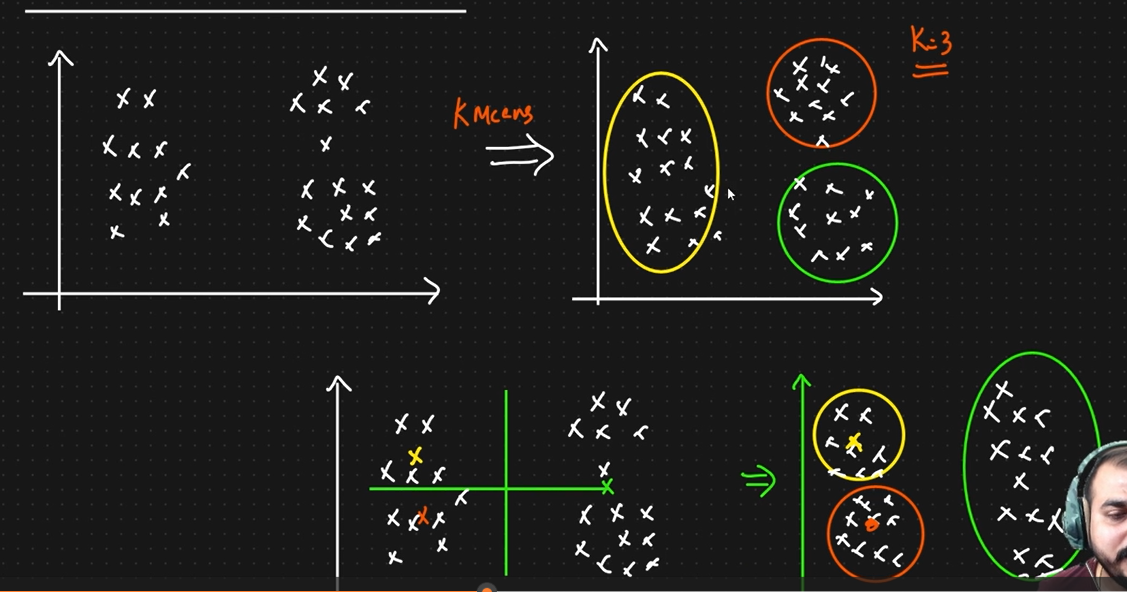


## 2. The Solution: K-Means++

To solve this trap, David Arthur and Sergei Vassilvitskii introduced **K-Means++**. Instead of initializing all centroids completely at random, K-Means++ uses a smart, probabilistic approach to spread the initial centroids as far apart from each other as possible before the actual clustering loop begins.

### The K-Means++ Step-by-Step Initialization Algorithm

* **Step 1:** Choose the first centroid ($c_1$) completely at random from the data points.
* **Step 2:** For each remaining data point $x_i$, compute its squared Euclidean distance to the nearest, already established centroid:
  $$D(x_i)^2 = \min ||x_i - c_k||^2 \quad \text{for } k \in \{1, 2, \dots, \text{current centroids}\}$$
* **Step 3:** Select the next centroid ($c_{next}$) from the dataset using a weighted probability distribution. The probability $P(x_i)$ of choosing point $x_i$ as the next centroid is proportional to its squared distance:
  $$P(x_i) = \frac{D(x_i)^2}{\sum_{j=1}^{n} D(x_j)^2}$$
  *(This ensures points that are extremely far away from existing centroids have the highest chance of selection, while nearby points are skipped).*
* **Step 4:** Repeat Steps 2 and 3 until all $K$ centroids have been successfully initialized.
* **Step 5:** Proceed with the standard K-Means algorithm iteration (assign points, update means).

## Conceptual Comparison: Standard vs. K-Means++

| Algorithmic Aspect | Standard K-Means (Random) | K-Means++ |
| :--- | :--- | :--- |
| **Initialization Method** | 100% Random selection | Probabilistic, distance-weighted selection |
| **Centroid Distribution** | Centroids can easily clump together | Centroids are guaranteed to be spread out |
| **Risk of Local Minima** | Highly vulnerable to bad local traps | Significantly reduced risk |
| **Convergence Speed** | Often takes more iterations to stabilize | Converges much faster because it starts in optimal zones |



# Advanced Cluster Evaluation: Knee Locator and Silhouette Scoring

---

When finding the optimal number of clusters ($K$) for unsupervised models like K-Means, visual evaluation of an Elbow plot can be subjective. To solve this, data scientists use automated mathematical detection via the **Kneedle Algorithm** alongside structural validation via **Silhouette Scoring**.


## 1. The Kneedle Algorithm (Knee/Elbow Locator)

The **Kneedle Algorithm** provides a rigorous mathematical foundation to automatically locate the "elbow" or "knee" point in a discrete curve, eliminating human bias.

In a standard Within-Cluster Sum of Squares (WCSS) plot against $K$, the curve drops rapidly before flattening out. The algorithm looks for the point of maximum curvature.

### Mathematical Mechanism

1. **Normalization:** The algorithm maps both the $x$ values ($K$ clusters) and $y$ values ($\text{WCSS}$) onto a normalized scale between $0$ and $1$:
   $$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}, \quad y_{norm} = \frac{y - y_{min}}{y_{max} - y_{min}}$$

2. **Difference Curve Calculation:** Because a standard elbow curve decreases, a straight diagonal baseline is drawn from the first point $(0,1)$ to the last point $(1,0)$. The algorithm calculates a distance metric known as the difference curve ($y_{diff}$):
   $$y_{diff} = x_{norm} + y_{norm} - 1$$

3. **Peak Detection:** The optimal "knee" or "elbow" is defined as the coordinate where the difference curve achieves its maximum local value before dropping off.

>  **Colab Note:** In Python, this is implemented using the popular library open-source package `kneed` via `KneeLocator(x, y, curve='convex', direction='decreasing')`.


## 2. Silhouette Scoring

While WCSS only calculates how close points are to their own centers, **Silhouette Scoring** evaluates the entire cluster topology. It balances two main aspects: **cohesion** (how close a point is to its own cluster) and **separation** (how far a point is from neighboring clusters).

### The Silhouette Coefficient Formula

For any single data point $i$, its individual silhouette coefficient $s(i)$ is defined as:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where:
* $a(i)$: The **mean intra-cluster distance** between point $i$ and all other data points inside the same cluster. (Measures cohesion; lower is better).
* $b(i)$: The **mean nearest-cluster distance** between point $i$ and all points in the closest neighboring cluster. (Measures separation; higher is better).

### Interpreting the Score Range

The value of $s(i)$ is strictly bounded between **$-1$** and **$+1$**:

* **接近 $+1$ (Strong Clustering):** Indicates that $a(i) \ll b(i)$. The point is deeply embedded within its correct cluster and far away from neighboring zones.
* **接近 $0$ (Overlapping Boundaries):** Indicates that $a(i) \approx b(i)$. The point sits directly on the decision boundary dividing two separate clusters.
* **接近 $-1$ (Misclassified Points):** Indicates that $a(i) \gg b(i)$. The point has been assigned to the wrong cluster group and is closer to a neighbor.

The global **Silhouette Score** for a model is the average $s(i)$ across every single point in the entire dataset.


## Conceptual Comparison: Knee / Elbow vs. Silhouette

| Evaluation Metric | The Elbow / Knee Method (WCSS) | Silhouette Analysis |
| :--- | :--- | :--- |
| **Learning Type** | Internal metric (computes distance to home center) | Relational metric (computes home vs. neighbor distance) |
| **Optimal Goal** | Find the inflection bend point using a knee locator | Find the value of $K$ that maximizes the overall score |
| **Sensitivity** | Highly sensitive to global dataset scale changes | Scale-invariant (standardized bounds between -1 and +1) |
| **Computation Cost**| Extremely low and fast to calculate | High ($O(N^2)$ matrix calculations for all point pairs) |


# ***Implement K-means Algorithm***

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
%matplotlib inline


In [102]:
x,y=make_blobs(n_samples=1000,n_features=2,centers=3)
x

array([[10.54980067, -5.23457231],
       [ 9.88245125,  1.35294332],
       [-8.02641661, -5.79301593],
       ...,
       [-7.95444311, -5.42476985],
       [10.02616314, -5.7180704 ],
       [ 8.47640076, -5.55207017]])

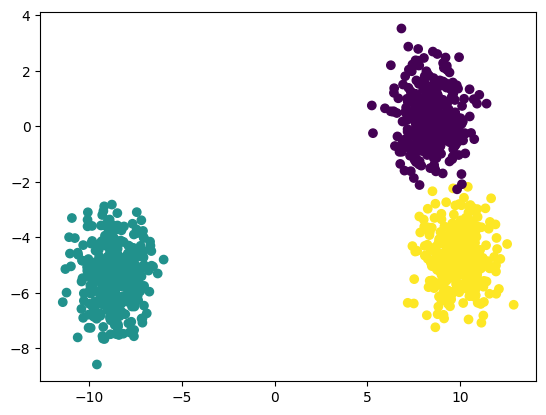

In [103]:
plt.scatter(x[:,0],x[:,1],c=y)

In [104]:
##Standarization-feature scaling technique
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.25,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[ 0.86777735, -0.7146859 ],
       [ 0.78871539,  1.66677081],
       [-1.33297714, -0.91656919],
       ...,
       [-1.32445032, -0.78344433],
       [ 0.80574117, -0.88947559],
       [ 0.62213831, -0.82946474]])

In [105]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [106]:
from sklearn.cluster import KMeans

#Elbow methpod to slelecet k valuse
wcss=[]
k_rng=range(1,11)
for k in k_rng:
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(x_train_scaled)
  wcss.append(kmeans.inertia_)

In [107]:
wcss


[1499.9999999999993,
 401.5599430887783,
 92.73401527987102,
 79.19146466999518,
 69.77117597324327,
 63.8359987378346,
 51.97082774349853,
 47.9885615935366,
 40.51403009798338,
 37.58543906474994]

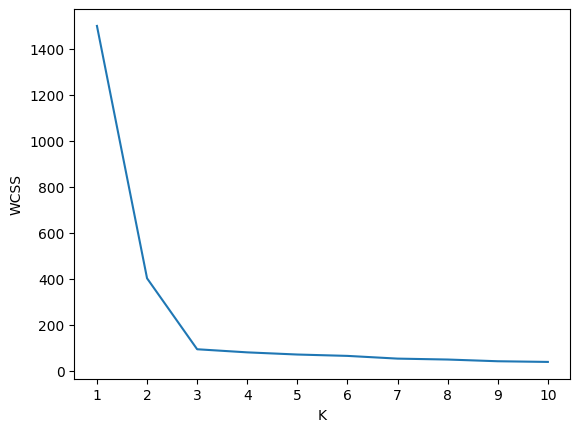

In [108]:
#Plot elbow curve
plt.plot(k_rng,wcss)
plt.xticks(k_rng)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

In [109]:
kemans=KMeans(n_clusters=3,init='k-means++')
kemans.fit_predict(x_train_scaled)
y_pred=kemans.fit_predict(x_test_scaled)

In [110]:
print(kemans.fit_predict(x_train_scaled))

[2 0 0 1 0 1 1 1 2 2 1 2 2 1 2 1 0 2 2 0 0 1 1 1 2 2 1 0 0 0 1 1 0 0 0 2 1
 2 1 2 0 1 2 2 2 1 0 2 2 0 2 0 2 0 0 0 2 0 0 0 2 0 0 1 2 0 1 2 2 0 0 1 2 1
 1 2 2 2 2 2 1 1 1 0 0 1 0 0 2 2 1 2 0 2 2 0 0 1 0 0 2 0 2 1 1 2 2 1 0 2 2
 2 0 2 0 2 0 1 0 0 0 2 2 1 2 1 1 0 1 0 2 1 2 0 2 1 0 2 2 1 2 2 2 2 1 1 2 1
 0 1 2 1 1 2 1 0 0 2 2 1 1 2 0 2 2 1 1 2 0 1 0 2 0 2 0 1 2 1 2 2 2 0 2 0 1
 1 0 1 0 2 0 0 2 2 1 0 0 0 1 2 2 0 2 2 1 2 1 0 0 0 0 1 0 0 0 1 2 2 1 2 0 0
 1 2 0 1 1 2 2 1 0 0 0 2 0 2 0 0 1 2 1 0 2 1 2 1 1 0 2 0 0 0 0 2 1 1 1 2 0
 2 1 0 1 2 1 0 0 1 1 0 1 2 0 0 1 0 0 1 0 0 2 2 0 2 0 2 2 0 2 0 0 1 2 1 1 2
 1 2 1 2 1 0 1 1 2 1 1 2 0 2 2 2 0 1 1 0 0 2 1 2 0 0 0 2 1 2 0 1 1 2 0 0 1
 1 0 2 1 1 1 2 0 1 1 0 2 1 0 2 2 2 0 2 0 1 2 0 2 2 0 2 0 1 2 1 0 1 0 2 0 1
 2 2 2 2 1 0 0 2 0 0 1 1 2 2 1 2 1 2 1 0 0 0 1 2 0 2 1 1 0 1 1 2 0 1 0 1 1
 2 1 1 1 2 2 0 1 1 2 0 2 0 1 1 1 2 2 1 2 0 1 0 1 0 1 0 0 1 2 1 1 0 1 1 0 1
 2 1 1 0 1 0 1 2 2 0 1 1 0 2 2 2 1 0 2 1 1 0 1 2 2 1 1 2 0 0 1 0 2 1 0 0 2
 0 0 1 1 0 2 2 0 0 2 2 1 

In [111]:
y_pred

array([2, 0, 1, 2, 1, 1, 1, 2, 1, 0, 0, 0, 2, 0, 2, 1, 0, 1, 1, 2, 0, 0,
       0, 0, 0, 1, 1, 1, 2, 0, 2, 2, 1, 0, 2, 2, 2, 2, 0, 0, 0, 2, 1, 0,
       0, 2, 0, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 2, 2, 0, 0,
       0, 1, 0, 2, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 0, 2, 1,
       1, 1, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 0, 1, 0, 2, 1,
       2, 0, 0, 0, 1, 1, 1, 2, 1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 0, 1, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 0, 2, 1, 2,
       0, 2, 2, 0, 0, 2, 1, 0, 1, 0, 1, 2, 0, 2, 1, 0, 2, 2, 0, 0, 1, 1,
       1, 0, 2, 2, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 2,
       2, 2, 1, 2, 0, 1, 2, 0, 2, 0, 1, 0, 1, 0, 2, 0, 0, 1, 1, 2, 1, 1,
       2, 1, 0, 1, 1, 0, 2, 2, 2, 0, 0, 2, 0, 1, 0, 1, 0, 2, 0, 0, 0, 2,
       1, 1, 1, 2, 2, 0, 0, 2], dtype=int32)

np.int64(3)

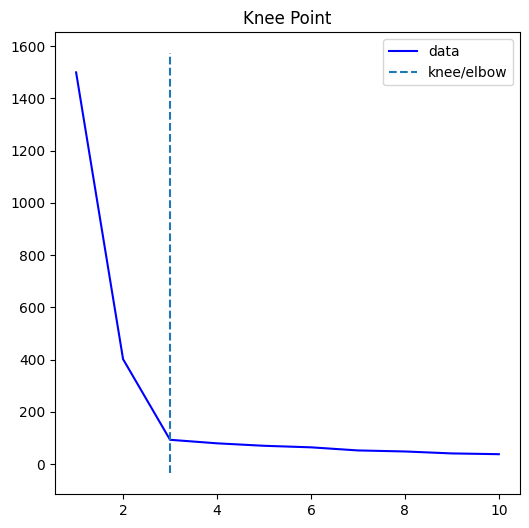

In [112]:
#Validating k valus by using
#1.Kneelocator
#2.Silhoutee Scoring

!pip install kneed
from kneed import KneeLocator
kl=KneeLocator(k_rng,wcss,curve='convex',direction='decreasing')
kl.ellow_curve='convex'
kl.direction='decreasing'
kl.plot_knee()
kl.knee



kl.elbow

In [113]:
#for silhoutte scoring
from sklearn.metrics import silhouette_score
sil_score=[]
k_rng=range(2,11)
for k in k_rng:
  kemans=KMeans(n_clusters=k,init='k-means++')
  kemans.fit_predict(x_train_scaled)
  sil_score.append(silhouette_score(x_train_scaled,kemans.labels_))

In [114]:
sil_score

[np.float64(0.6789995315404662),
 np.float64(0.7482245800338321),
 np.float64(0.6116488757829395),
 np.float64(0.49854824357983074),
 np.float64(0.4501071844232145),
 np.float64(0.347331692630107),
 np.float64(0.33071644322042815),
 np.float64(0.3381700838349557),
 np.float64(0.34184414266376123)]

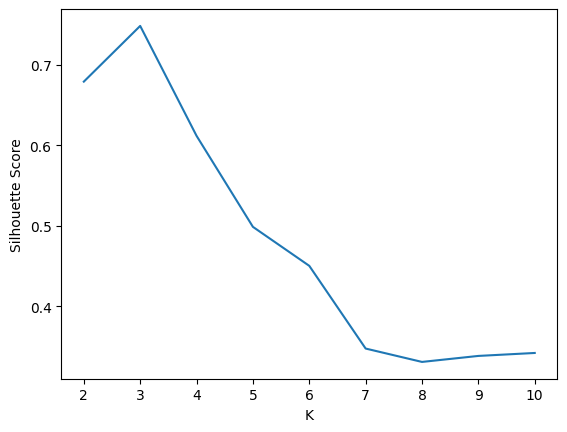

In [115]:
#plotfor silhoutte scoring
plt.plot(k_rng,sil_score)
plt.xticks(k_rng)
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()